In [1]:
#pip install matplotlib

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import joblib


In [3]:
df = pd.read_csv("employee_performance_dataset.csv")

df.head()


,task_delay_days,avg_task_completion_time,department_rating,attendance_percentage,days_absent,skill_level,years_experience,projects_completed,client_feedback_score,training_hours,overtime_hours,errors_reported,teamwork_score,productivity_score,performance
0,19,4.93,2,73,18,2,2,5,1,10,5,15,1,-8.1,Low
1,20,4.70,1,70,12,2,1,1,1,6,2,13,2,-21.0,Low
2,13,5.46,2,67,13,1,0,4,1,5,3,8,2,11.1,Low
3,12,7.77,1,66,22,1,1,3,1,10,4,13,2,-12.2,Low
4,19,7.08,2,71,16,2,2,1,1,4,5,12,1,-7.7,Low


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   task_delay_days           6000 non-null   int64  
 1   avg_task_completion_time  6000 non-null   float64
 2   department_rating         6000 non-null   int64  
 3   attendance_percentage     6000 non-null   int64  
 4   days_absent               6000 non-null   int64  
 5   skill_level               6000 non-null   int64  
 6   years_experience          6000 non-null   int64  
 7   projects_completed        6000 non-null   int64  
 8   client_feedback_score     6000 non-null   int64  
 9   training_hours            6000 non-null   int64  
 10  overtime_hours            6000 non-null   int64  
 11  errors_reported           6000 non-null   int64  
 12  teamwork_score            6000 non-null   int64  
 13  productivity_score        6000 non-null   float64
 14  performa

In [5]:
df["performance"].value_counts()


Low       2000
Medium    2000
High      2000
Name: performance, dtype: int64

In [6]:
le = LabelEncoder()
df["performance_encoded"] = le.fit_transform(df["performance"])

df[["performance", "performance_encoded"]].head()


,performance,performance_encoded
0,Low,1
1,Low,1
2,Low,1
3,Low,1
4,Low,1


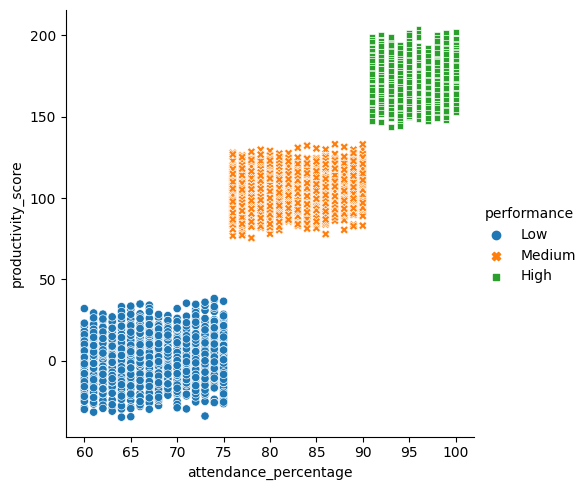

In [7]:
sns.relplot(
    data=df,
    x="attendance_percentage",
    y="productivity_score",
    hue="performance",
    style="performance",
    height=5
)
plt.show()


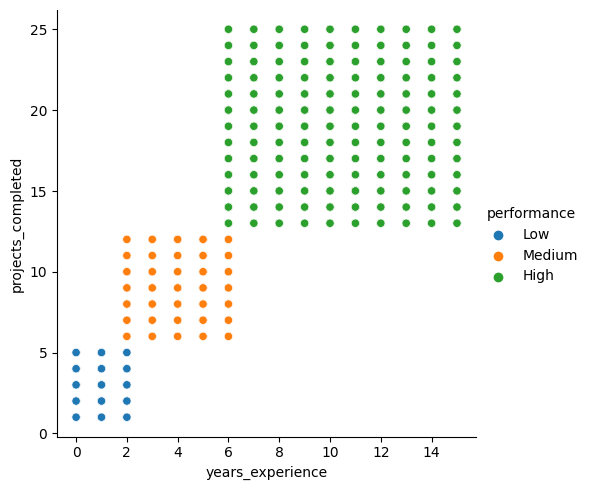

In [8]:
sns.relplot(
    data=df,
    x="years_experience",
    y="projects_completed",
    hue="performance",
    height=5
)
plt.show()


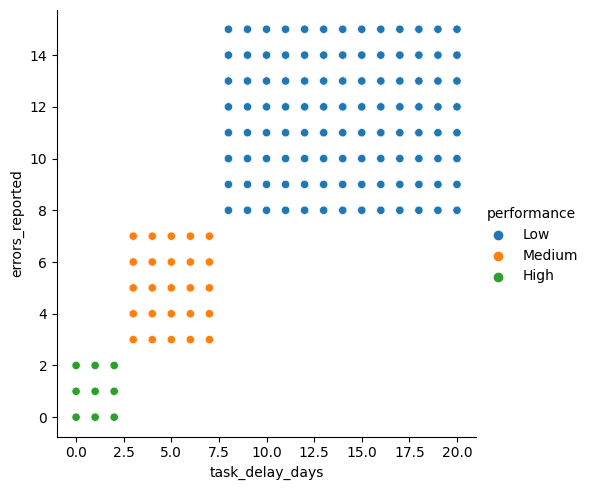

In [9]:
sns.relplot(
    data=df,
    x="task_delay_days",
    y="errors_reported",
    hue="performance",
    height=5
)
plt.show()


In [10]:
X = df.drop(columns=["performance", "performance_encoded"])
y = df["performance_encoded"]


In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [12]:
lasso = Lasso(alpha=0.01)
lasso.fit(X_scaled, y)

lasso_coef = pd.Series(lasso.coef_, index=X.columns)

lasso_coef.sort_values(ascending=False)


teamwork_score              0.167909
skill_level                 0.155678
department_rating           0.141976
client_feedback_score       0.134300
avg_task_completion_time   -0.000000
attendance_percentage      -0.000000
productivity_score          0.000000
errors_reported            -0.042977
days_absent                -0.151683
task_delay_days            -0.173678
years_experience           -0.315712
projects_completed         -0.361634
overtime_hours             -0.366133
training_hours             -0.369471
dtype: float64

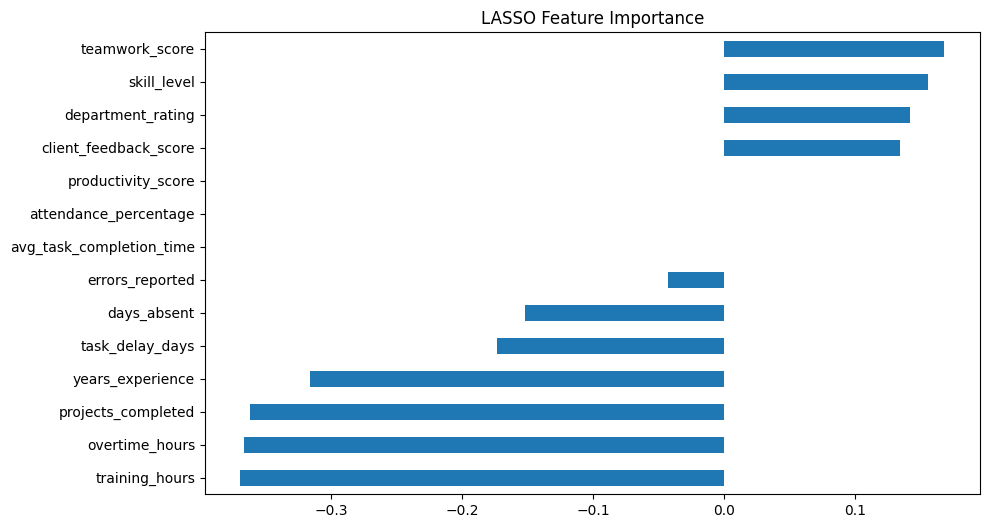

In [13]:
plt.figure(figsize=(10,6))
lasso_coef.sort_values().plot(kind="barh")
plt.title("LASSO Feature Importance")
plt.show()


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [15]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    random_state=42
)

rf_model.fit(X_train, y_train)


RandomForestClassifier(max_depth=12, n_estimators=200, random_state=42)

In [16]:
y_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       400
           1       1.00      1.00      1.00       400
           2       1.00      1.00      1.00       400

    accuracy                           1.00      1200
   macro avg       1.00      1.00      1.00      1200
weighted avg       1.00      1.00      1.00      1200



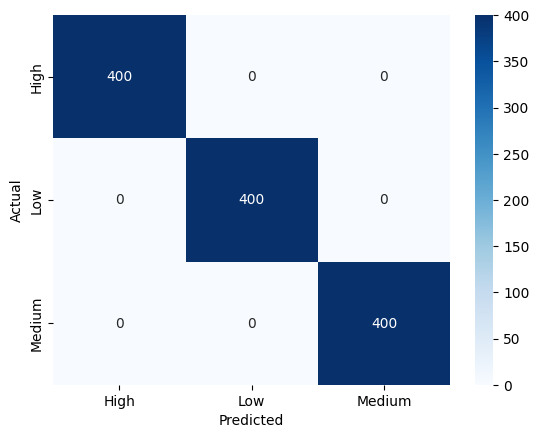

In [17]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [18]:
joblib.dump(rf_model, "employee_performance_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(le, "label_encoder.pkl")

print("✅ Model & scaler saved")


✅ Model & scaler saved


In [19]:
model = joblib.load("employee_performance_model.pkl")
scaler = joblib.load("scaler.pkl")
label_encoder = joblib.load("label_encoder.pkl")


In [25]:
employee_data = {
    "task_delay_days": 1,
    "avg_task_completion_time": 5.5,
    "department_rating": 5,
    "attendance_percentage": 96,
    "days_absent": 1,
    "skill_level": 5,
    "years_experience": 8,
    "projects_completed": 18,
    "client_feedback_score": 5,
    "training_hours": 40,
    "overtime_hours": 20,
    "errors_reported": 1,
    "teamwork_score": 5,
    "productivity_score": 185
}


In [26]:
employee_df = pd.DataFrame([employee_data])

employee_scaled = scaler.transform(employee_df)


In [27]:
prediction = model.predict(employee_scaled)
prediction_label = label_encoder.inverse_transform(prediction)

print("Predicted Performance:", prediction_label[0])


Predicted Performance: Low


C:\Users\HP\anaconda3\envs\smartai\lib\site-packages\sklearn\base.py:451: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  "X does not have valid feature names, but"
